In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/idh-mutation/train_labels.csv
/kaggle/input/glioma-grading-clinical-and-mutation-features/TCGA_InfoWithGrade.csv
/kaggle/input/glioma-grading-clinical-and-mutation-features/TCGA_GBM_LGG_Mutations_all.csv
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/sample_submission.csv
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/train_labels.csv
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/test/00114/T2w/Image-4.dcm
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/test/00114/T2w/Image-2.dcm
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/test/00114/T2w/Image-3.dcm
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/test/00114/T2w/Image-5.dcm
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/test/00114/T2w/Image-19.dcm
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/test/00114/T2w/Image-16.dcm
/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-

In [2]:
!pip install kaggle


In [4]:
!pip install nibabel matplotlib scikit-learn tensorflow keras


In [5]:
!pip install opencv-python-headless nibabel scikit-image matplotlib pandas Pillow tensorflow keras


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 91.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.0.2 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, 

In [7]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


dataset path

In [8]:
TRAIN_DATASET_PATH = "/kaggle/input/brats2023-full/BraTS2023"

In [9]:
import nibabel as nib  
test_image_flair = nib.load("/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-seg.nii").get_fdata()
print("Shape: ", test_image_flair.shape)
print("Dtype: ", test_image_flair.dtype)

Shape:  (240, 240, 155)
Dtype:  float64


In [9]:
print("Min: ", test_image_flair.min())
print("Max: ", test_image_flair.max())

Min:  0.0
Max:  3.0


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [11]:
test_image_flair = scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)

In [12]:
print("Min: ", test_image_flair.min())
print("Max: ", test_image_flair.max())

Min:  0.0
Max:  1.0


In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

#  Dataset Path
DATASET_PATH = "/kaggle/input/brats2023-full/BraTS2023"
scaler = MinMaxScaler()

#Exploration
def explore_brats_dataset(path=DATASET_PATH):
    patients = sorted([p for p in os.listdir(path) if p.startswith("BraTS-GLI")])
    print(f"Total Patients Found: {len(patients)}\n")
    
   
    records = []
    for pid in patients[:5]:
        ppath = os.path.join(path, pid)
        files = os.listdir(ppath)
        records.append({
            "Patient_ID": pid,
            "Files": files
        })
    df = pd.DataFrame(records)
    print(df)
    return patients

patients = explore_brats_dataset()


Total Patients Found: 1251

            Patient_ID                                              Files
0  BraTS-GLI-00000-000  [BraTS-GLI-00000-000-t1n.nii, BraTS-GLI-00000-...
1  BraTS-GLI-00002-000  [BraTS-GLI-00002-000-t1c.nii, BraTS-GLI-00002-...
2  BraTS-GLI-00003-000  [BraTS-GLI-00003-000-seg.nii, BraTS-GLI-00003-...
3  BraTS-GLI-00005-000  [BraTS-GLI-00005-000-seg.nii, BraTS-GLI-00005-...
4  BraTS-GLI-00006-000  [BraTS-GLI-00006-000-t1n.nii, BraTS-GLI-00006-...


In [ ]:
def load_and_rescale_modalities(patient_id, base_path=DATASET_PATH):
    """
    Load t1n, t1c, t2f, t2w, seg from a BraTS 2023 patient folder.
    Rescale each image to [0,1] using MinMaxScaler.
    """
    pdir = os.path.join(base_path, patient_id)

    def rescale_volume(img_path):
        img = nib.load(img_path).get_fdata()
        flat = img.reshape(-1, 1)
        scaled = scaler.fit_transform(flat).reshape(img.shape)
        return scaled.astype(np.float32)

   
    t1n = rescale_volume(os.path.join(pdir, f"{patient_id}-t1n.nii"))
    t1c = rescale_volume(os.path.join(pdir, f"{patient_id}-t1c.nii"))
    t2f = rescale_volume(os.path.join(pdir, f"{patient_id}-t2f.nii"))
    t2w = rescale_volume(os.path.join(pdir, f"{patient_id}-t2w.nii"))
    seg = nib.load(os.path.join(pdir, f"{patient_id}-seg.nii")).get_fdata().astype(np.uint8)

    return t1n, t1c, t2f, t2w, seg


In [ ]:
pid = patients[0]
print(f"\nInspecting patient: {pid}")

t1n, t1c, t2f, t2w, seg = load_and_rescale_modalities(pid)

print("Shapes:")
print("T1n:", t1n.shape)
print("T1c:", t1c.shape)
print("T2f:", t2f.shape)
print("T2w:", t2w.shape)
print("Seg:", seg.shape)

print("\nValue ranges:")
print("T1n:", (np.min(t1n), np.max(t1n)))
print("Seg unique labels:", np.unique(seg))



Inspecting patient: BraTS-GLI-00000-000
Shapes:
T1n: (240, 240, 155)
T1c: (240, 240, 155)
T2f: (240, 240, 155)
T2w: (240, 240, 155)
Seg: (240, 240, 155)

Value ranges:
T1n: (0.0, 1.0)
Seg unique labels: [0 1 2 3]


In [ ]:
# Stack modalities into one 4-channel 3D array (C, H, W, D)
image_4ch = np.stack([t1n, t1c, t2f, t2w], axis=0)
print("\nStacked image shape:", image_4ch.shape)
os.makedirs("/content/preprocessed", exist_ok=True)
np.save(f"/content/preprocessed/{pid}_img.npy", image_4ch)
np.save(f"/content/preprocessed/{pid}_mask.npy", seg)



Stacked image shape: (4, 240, 240, 155)


Slice Number: 95


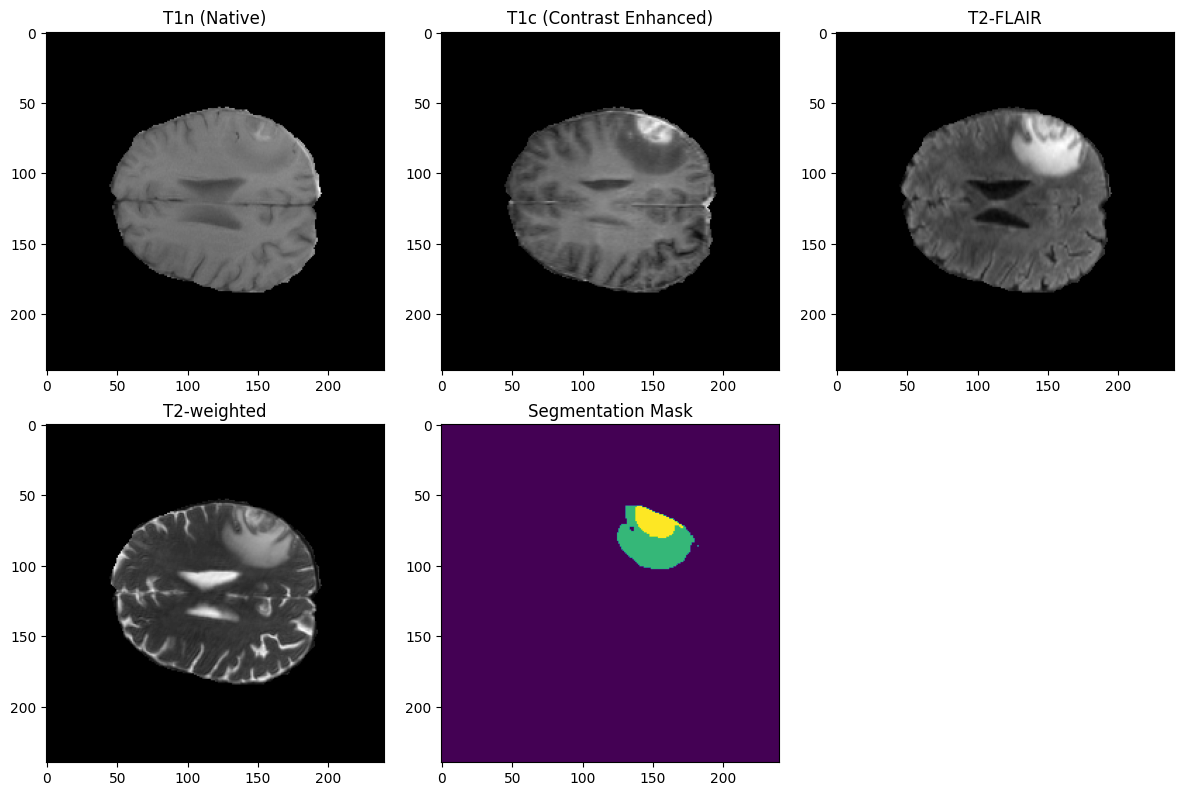

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

# Set slice number
slice_num = 95
print(f"Slice Number: {slice_num}")

# Define patient folder
patient_path = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00011-000"

# Load NIfTI files 
t1n  = nib.load(f"{patient_path}/BraTS-GLI-00011-000-t1n.nii").get_fdata()
t1c  = nib.load(f"{patient_path}/BraTS-GLI-00011-000-t1c.nii").get_fdata()
t2f  = nib.load(f"{patient_path}/BraTS-GLI-00011-000-t2f.nii").get_fdata()
t2w  = nib.load(f"{patient_path}/BraTS-GLI-00011-000-t2w.nii").get_fdata()
mask = nib.load(f"{patient_path}/BraTS-GLI-00011-000-seg.nii").get_fdata()

# Plot each modality and segmentation mask
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(t1n[:, :, slice_num], cmap='gray')
plt.title('T1n (Native)')

plt.subplot(2, 3, 2)
plt.imshow(t1c[:, :, slice_num], cmap='gray')
plt.title('T1c (Contrast Enhanced)')

plt.subplot(2, 3, 3)
plt.imshow(t2f[:, :, slice_num], cmap='gray')
plt.title('T2-FLAIR')

plt.subplot(2, 3, 4)
plt.imshow(t2w[:, :, slice_num], cmap='gray')
plt.title('T2-weighted')

plt.subplot(2, 3, 5)
plt.imshow(mask[:, :, slice_num])
plt.title('Segmentation Mask')

plt.tight_layout()
plt.show()


In [ ]:
import nibabel as nib


modality_path = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00011-000/BraTS-GLI-00011-000-t1n.nii"
seg_path      = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00011-000/BraTS-GLI-00011-000-seg.nii"
modality_img = nib.load(modality_path).get_fdata()
seg_img = nib.load(seg_path).get_fdata()
print("Modality shape:", modality_img.shape)
print("Segmentation shape:", seg_img.shape)


Modality shape: (240, 240, 155)
Segmentation shape: (240, 240, 155)


Slice number: 95


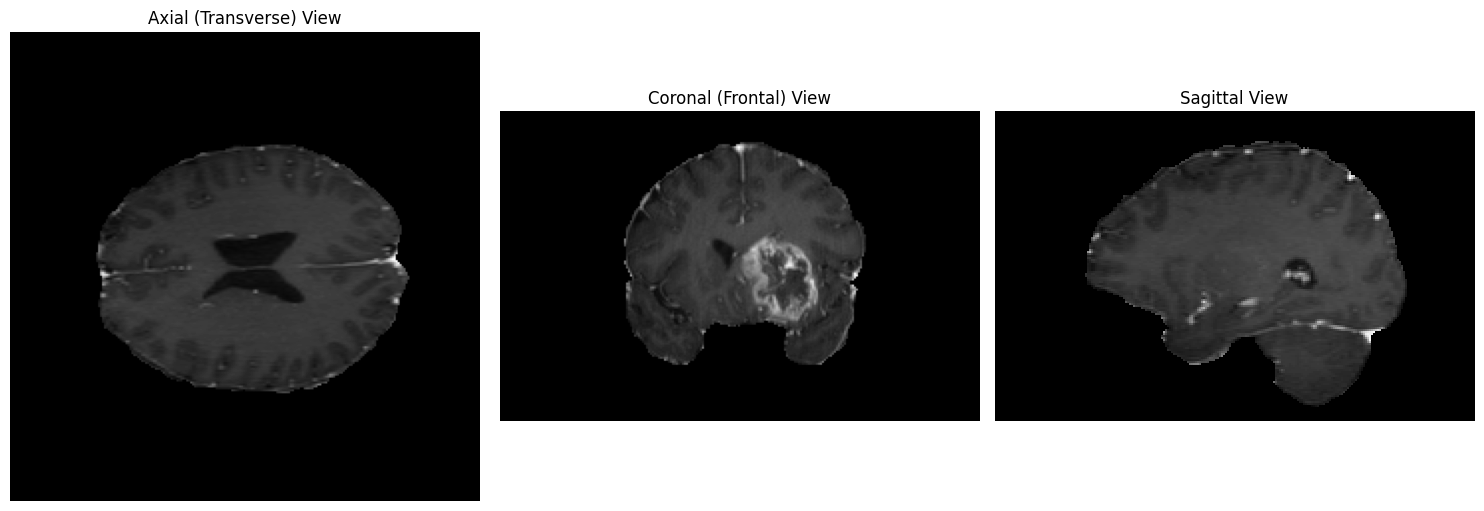

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# Load a T1CE example
t1ce_path = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii"
test_image_t1ce = nib.load(t1ce_path).get_fdata()

# slice index
slice_num = 95
print(f"Slice number: {slice_num}")

plt.figure(figsize=(15, 5))

#  Axial (Transverse) View ---
plt.subplot(1, 3, 1)
plt.imshow(test_image_t1ce[:, :, slice_num], cmap='gray')
plt.title('Axial (Transverse) View')
plt.axis('off')

# Coronal (Frontal) View ---
plt.subplot(1, 3, 2)
plt.imshow(rotate(test_image_t1ce[:, slice_num, :], 90, reshape=True), cmap='gray')
plt.title('Coronal (Frontal) View')
plt.axis('off')

# Sagittal View ---
plt.subplot(1, 3, 3)
plt.imshow(rotate(test_image_t1ce[slice_num, :, :], 90, reshape=True), cmap='gray')
plt.title('Sagittal View')
plt.axis('off')

plt.tight_layout()
plt.show()


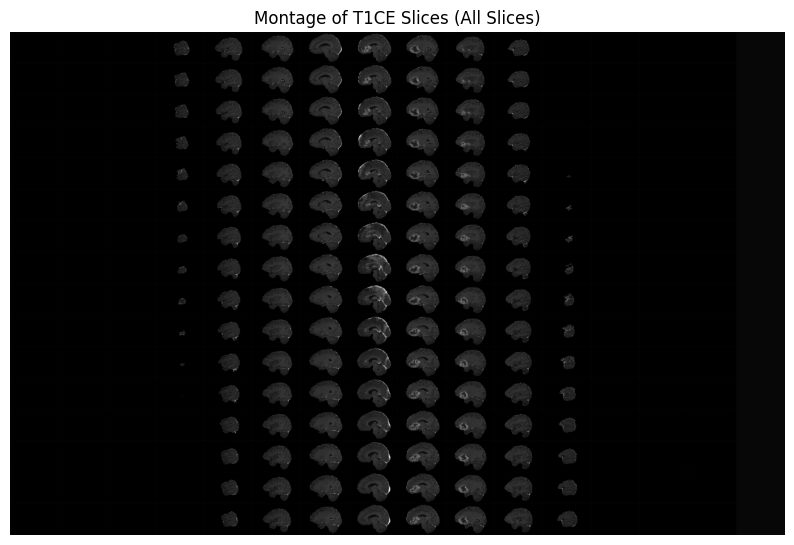

In [19]:
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.util import montage

# Load a T1CE volume (example)
t1ce_path = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii"
test_image_t1ce = nib.load(t1ce_path).get_fdata()

# Create montage from all slices
montage_img = montage(test_image_t1ce, grid_shape=None, padding_width=2)

# Plot rotated montage
plt.figure(figsize=(10, 10))
plt.imshow(rotate(montage_img, 90, reshape=True), cmap='gray')
plt.title('Montage of T1CE Slices (All Slices)')
plt.axis('off')
plt.show()


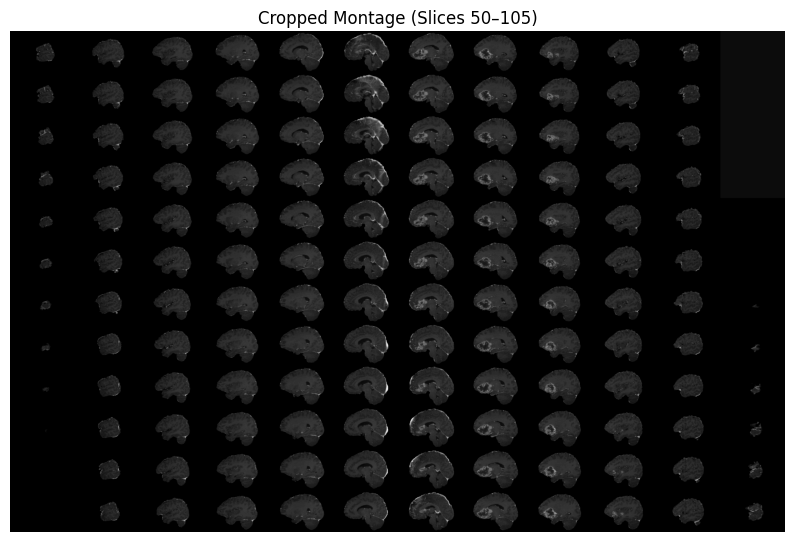

In [20]:
plt.figure(figsize=(10, 10))
plt.imshow(rotate(montage(test_image_t1ce[50:-50,:,:]), 90, reshape=True), cmap='gray')
plt.title('Cropped Montage (Slices 50–105)')
plt.axis('off')
plt.show()


In [21]:
!pip install matplotlib
!pip install scipy
!pip install scikit-image


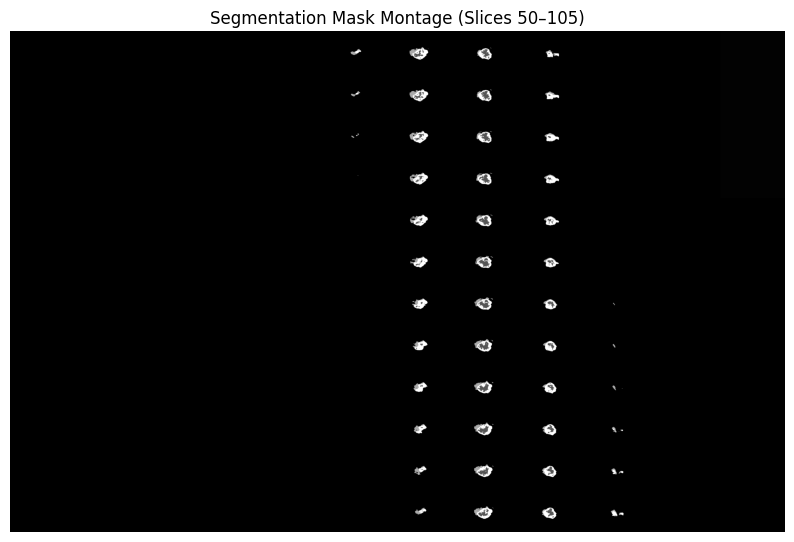

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.util import montage

# Load the segmentation volume 
seg_path = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-seg.nii"
test_image_seg = nib.load(seg_path).get_fdata()

#  visualize montage 
plt.figure(figsize=(10, 10))
plt.imshow(rotate(montage(test_image_seg[50:-50, :, :]), 90, reshape=True), cmap='gray')
plt.title('Segmentation Mask Montage (Slices 50–105)')
plt.axis('off')
plt.show()


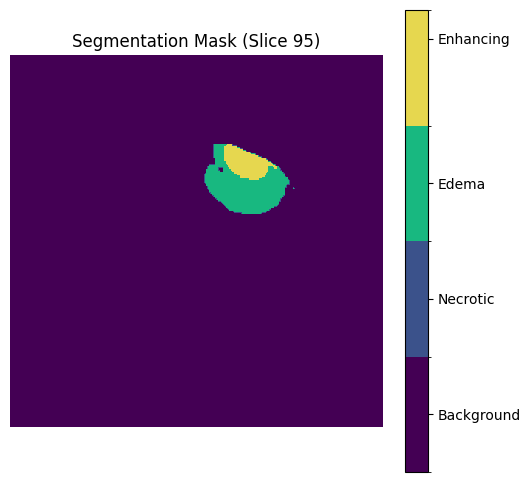

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


seg_path = "/kaggle/input/brats2023-full/BraTS2023/BraTS-GLI-00011-000/BraTS-GLI-00011-000-seg.nii"
test_image_seg = nib.load(seg_path).get_fdata()
cmap = mcolors.ListedColormap(['#440054', '#3b528b', '#18b880', '#e6d74f'])
bounds = [-0.5, 0.5, 1.5, 2.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Select slice
slice_num = 95

plt.figure(figsize=(6, 6))
plt.imshow(test_image_seg[:, :, slice_num], cmap=cmap, norm=norm)
cbar = plt.colorbar(ticks=[0, 1, 2, 4])
cbar.ax.set_yticklabels(['Background', 'Necrotic', 'Edema', 'Enhancing'])
plt.title(f'Segmentation Mask (Slice {slice_num})')
plt.axis('off')
plt.show()


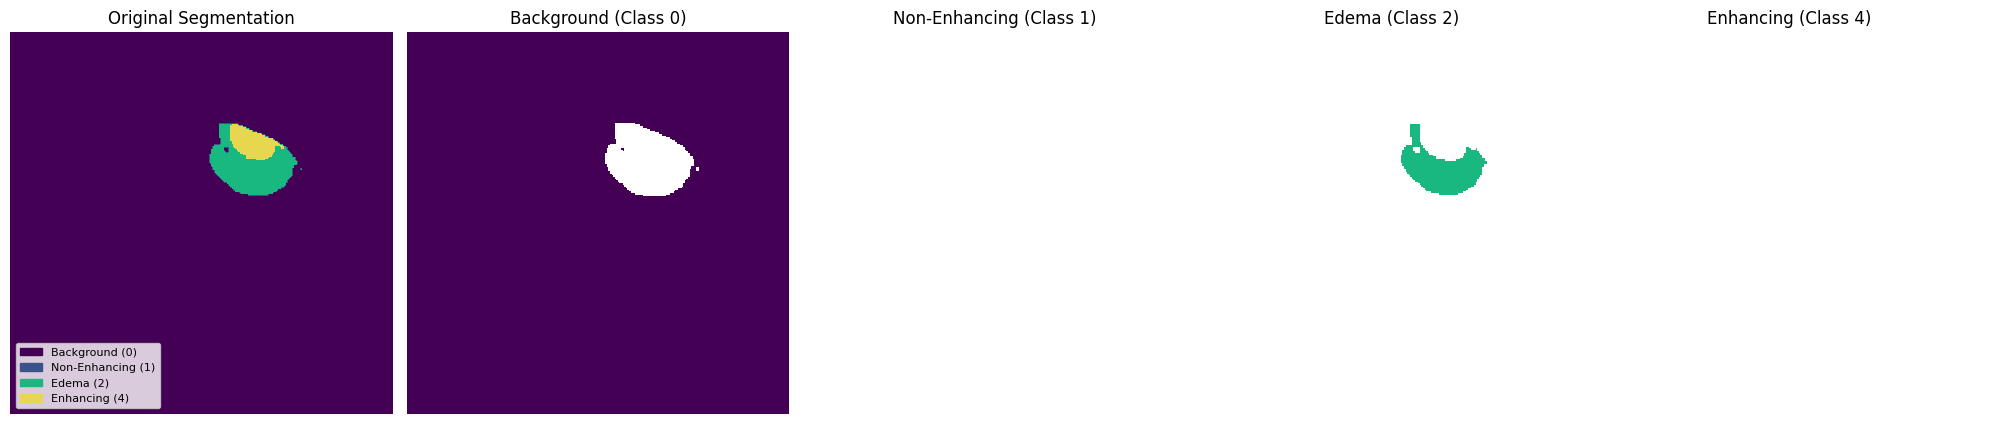

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


slice_num = 95

# Isolate each segmentation class
seg_0 = test_image_seg.copy()
seg_0[seg_0 != 0] = np.nan

seg_1 = test_image_seg.copy()
seg_1[seg_1 != 1] = np.nan

seg_2 = test_image_seg.copy()
seg_2[seg_2 != 2] = np.nan

seg_4 = test_image_seg.copy()
seg_4[seg_4 != 4] = np.nan

#  Define legend 
class_names = ['Background (0)', 'Non-Enhancing (1)', 'Edema (2)', 'Enhancing (4)']
legend = [plt.Rectangle((0, 0), 1, 1, color=cmap(i), label=class_names[i]) for i in range(len(class_names))]

# Plot 
fig, ax = plt.subplots(1, 5, figsize=(20, 5))

ax[0].imshow(test_image_seg[:, :, slice_num], cmap=cmap, norm=norm)
ax[0].set_title('Original Segmentation')
ax[0].legend(handles=legend, loc='lower left', fontsize=8)

ax[1].imshow(seg_0[:, :, slice_num], cmap=cmap, norm=norm)
ax[1].set_title('Background (Class 0)')

ax[2].imshow(seg_1[:, :, slice_num], cmap=cmap, norm=norm)
ax[2].set_title('Non-Enhancing (Class 1)')

ax[3].imshow(seg_2[:, :, slice_num], cmap=cmap, norm=norm)
ax[3].set_title('Edema (Class 2)')

ax[4].imshow(seg_4[:, :, slice_num], cmap=cmap, norm=norm)
ax[4].set_title('Enhancing (Class 4)')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()


Train length: 850
Validation length: 251
Test length: 150


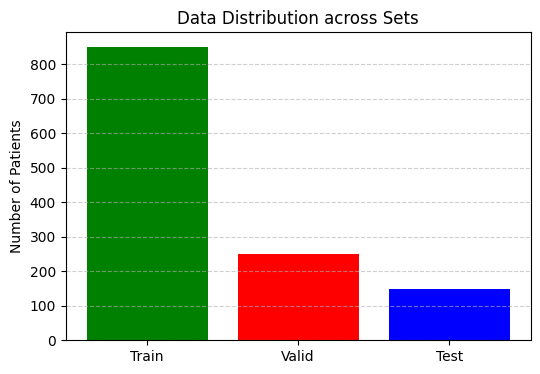

In [ ]:
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


TRAIN_DATASET_PATH = "/kaggle/input/brats2023-full/BraTS2023"

train_and_val_directories = [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]


def pathListIntoIds(dirList):
    return [os.path.basename(path) for path in dirList]

train_and_test_ids = pathListIntoIds(train_and_val_directories)


train_test_ids, val_ids = train_test_split(train_and_test_ids, test_size=0.2, random_state=42)
train_ids, test_ids = train_test_split(train_test_ids, test_size=0.15, random_state=42)


print(f"Train length: {len(train_ids)}")
print(f"Validation length: {len(val_ids)}")
print(f"Test length: {len(test_ids)}")

plt.figure(figsize=(6, 4))
plt.bar(["Train", "Valid", "Test"],
        [len(train_ids), len(val_ids), len(test_ids)],
        color=['green', 'red', 'blue'])
plt.ylabel('Number of Patients')
plt.title('Data Distribution across Sets')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
import cv2
from tensorflow import keras
from scipy.ndimage import zoom

# Define segmentation classes 
SEGMENT_CLASSES = {
    0: 'NOT tumor',
    1: 'NECROTIC/CORE',  
    2: 'EDEMA',
    3: 'ENHANCING'      
}

VOLUME_SLICES = 100
VOLUME_START_AT = 22
IMG_SIZE = 128
PATCH_SIZE = (128, 128, 128)  
TRAIN_DATASET_PATH = "/kaggle/input/brats2023-full/BraTS2023"
RADIOGENOMIC_LABELS_PATH = "/kaggle/input/brats2021-radiogenomic-classification/train_labels.csv"  

# Data Generator 
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras (2-channel: FLAIR + T1CE)'
    def __init__(self, list_IDs, dim=(IMG_SIZE, IMG_SIZE), batch_size=1, n_channels=2, shuffle=True):
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        Batch_ids = [self.list_IDs[k] for k in indexes]
        X, Y = self.__data_generation(Batch_ids)
        return X, Y

    def on_epoch_end(self):
        'Shuffle at the end of each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples'
        X = np.zeros((self.batch_size * VOLUME_SLICES, *self.dim, self.n_channels), dtype=np.float32)
        y = np.zeros((self.batch_size * VOLUME_SLICES, 240, 240), dtype=np.uint8)

        for c, pid in enumerate(Batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, pid)

            flair_path = os.path.join(case_path, f"{pid}-t2f.nii")
            t1ce_path  = os.path.join(case_path, f"{pid}-t1c.nii")
            seg_path   = os.path.join(case_path, f"{pid}-seg.nii")

            flair = nib.load(flair_path).get_fdata()
            t1ce  = nib.load(t1ce_path).get_fdata()
            seg   = nib.load(seg_path).get_fdata()

            for j in range(VOLUME_SLICES):
                slice_idx = j + VOLUME_START_AT
                if slice_idx >= flair.shape[2]:
                    break
                X[j + VOLUME_SLICES*c, :, :, 0] = cv2.resize(flair[:, :, slice_idx], self.dim)
                X[j + VOLUME_SLICES*c, :, :, 1] = cv2.resize(t1ce[:, :, slice_idx], self.dim)
                y[j + VOLUME_SLICES*c] = seg[:, :, slice_idx]

        
        X /= np.max(X)

        y[y == 4] = 3
        mask = tf.one_hot(y, depth=4)
        Y = tf.image.resize(mask, self.dim)
        return X, Y



class DataGenerator3D(keras.utils.Sequence):
    """Generates 3D MRI volumes (FLAIR + T1CE) + segmentation + optional IDH labels."""

    def __init__(self, list_IDs, patch_size=PATCH_SIZE, batch_size=1, shuffle=True, use_radiogenomics=False):
        self.patch_size = patch_size
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.shuffle = shuffle
        self.use_radiogenomics = use_radiogenomics
        self.on_epoch_end()

    def __len__(self):
        """Number of batches per epoch."""
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def on_epoch_end(self):
        """Shuffle indexes after each epoch."""
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __normalize(self, vol):
        vol = np.nan_to_num(vol)
        vmin, vmax = np.min(vol), np.max(vol)
        return (vol - vmin) / (vmax - vmin + 1e-6)

    def __resize_volume(self, img):
        """Resize 3D volume to PATCH_SIZE."""
        zoom_factors = (
            self.patch_size[0] / img.shape[0],
            self.patch_size[1] / img.shape[1],
            self.patch_size[2] / img.shape[2],
        )
        return zoom(img, zoom_factors, order=1)  

    def __getitem__(self, index):
        """Generate one batch."""
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_ids = [self.list_IDs[k] for k in indexes]
        return self.__data_generation(batch_ids)

    def __data_generation(self, batch_ids):
        """Load and preprocess MRI volumes."""
        X = np.zeros((self.batch_size, *self.patch_size, 2), dtype=np.float32)
        Y = np.zeros((self.batch_size, *self.patch_size), dtype=np.uint8)
        idh_labels = np.zeros((self.batch_size, 1), dtype=np.float32)

        for i, pid in enumerate(batch_ids):
            case_path = os.path.join(TRAIN_DATASET_PATH, pid)

        
            flair = nib.load(os.path.join(case_path, f"{pid}-t2f.nii")).get_fdata()
            t1ce  = nib.load(os.path.join(case_path, f"{pid}-t1c.nii")).get_fdata()
            seg   = nib.load(os.path.join(case_path, f"{pid}-seg.nii")).get_fdata()

    
            flair = self.__normalize(flair)
            t1ce  = self.__normalize(t1ce)
            flair = self.__resize_volume(flair)
            t1ce  = self.__resize_volume(t1ce)
            seg   = self.__resize_volume(seg)

        
            X[i, ...] = np.stack([flair, t1ce], axis=-1)
            seg[seg == 4] = 3
            Y[i, ...] = seg.astype(np.uint8)

            
            if self.use_radiogenomics:
                idh_labels[i, 0] = self.idh_dict.get(pid, 0)

    
        Y = tf.one_hot(Y, depth=4, dtype=tf.float32)

        
        if self.use_radiogenomics:
            return X, {"seg_output": Y, "idh_status": idh_labels}
        else:
            return X, Y




2025-11-04 17:50:12.858563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762278613.024607      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762278613.092869      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ X_batch shape: (100, 128, 128, 2)
✅ Y_batch shape: (100, 128, 128, 4)


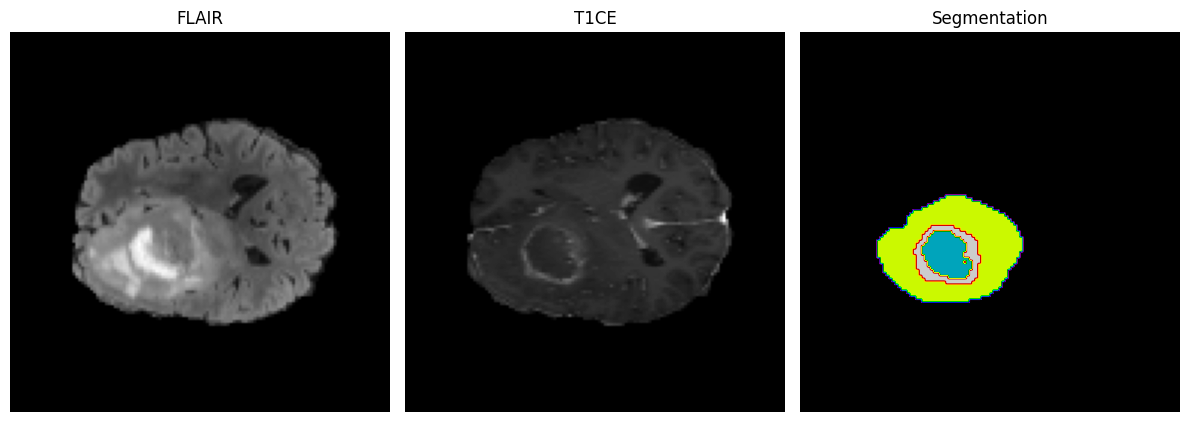

In [ ]:

def display_slice_and_segmentation(flair, t1ce, segmentation):
    """Displays a sample FLAIR, T1CE, and segmentation slice."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))

    axes[0].imshow(flair, cmap='gray')
    axes[0].set_title('FLAIR')
    axes[0].axis('off')

    axes[1].imshow(t1ce, cmap='gray')
    axes[1].set_title('T1CE')
    axes[1].axis('off')

    axes[2].imshow(segmentation, cmap='nipy_spectral', vmin=0, vmax=3)
    axes[2].set_title('Segmentation')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()



all_folders = sorted(os.listdir(TRAIN_DATASET_PATH))
sample_ids = all_folders[:2] 

training_generator = DataGenerator(sample_ids)

# Fetch one batch
X_batch, Y_batch = training_generator[0]
print(" X_batch shape:", X_batch.shape)
print(" Y_batch shape:", Y_batch.shape)

# Extract modalities and segmentation
flair_batch = X_batch[:, :, :, 0]
t1ce_batch = X_batch[:, :, :, 1]
segmentation_batch = np.argmax(Y_batch, axis=-1)

# Pick random slice to visualize
slice_index = np.random.randint(0, flair_batch.shape[0])
slice_flair = flair_batch[slice_index]
slice_t1ce = t1ce_batch[slice_index]
slice_segmentation = segmentation_batch[slice_index]

# Display the random slice
display_slice_and_segmentation(slice_flair, slice_t1ce, slice_segmentation)


In [29]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models, optimizers
import numpy as np

def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    dice_total = 0
    for i in range(class_num):
        y_true_f = K.flatten(y_true[:,:,:,i])
        y_pred_f = K.flatten(y_pred[:,:,:,i])
        intersection = K.sum(y_true_f * y_pred_f)
        dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
        dice_total += dice
    return dice_total / class_num

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss_fixed

def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)
    return 1 - ((true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth))

def combined_loss(y_true, y_pred):
    dl = dice_loss(y_true, y_pred)
    fl = focal_loss()(y_true, y_pred)
    tl = tversky_loss(y_true, y_pred)
    return 0.4 * dl + 0.3 * fl + 0.3 * tl


In [30]:
def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,1])) + K.sum(K.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,2])) + K.sum(K.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (K.sum(K.square(y_true[:,:,:,3])) + K.sum(K.square(y_pred[:,:,:,3])) + epsilon)


In [31]:
def precision(y_true, y_pred):
    true_pos = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    pred_pos = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return true_pos / (pred_pos + K.epsilon())

def sensitivity(y_true, y_pred):
    true_pos = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_pos = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_pos / (possible_pos + K.epsilon())

def specificity(y_true, y_pred):
    true_neg = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_neg = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_neg / (possible_neg + K.epsilon())


In [ ]:
def build_unet(input_shape=(128,128,2)):
    inputs = layers.Input(shape=input_shape)
    
  
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(bn)

  
    u3 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(bn)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    u1 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(4, (1, 1), activation='softmax')(c6)
    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

model = build_unet((128, 128, 2))
model.compile(optimizer='adam',
              loss=combined_loss,
              metrics=[dice_coef, dice_coef_necrotic, dice_coef_edema, dice_coef_enhancing,
                       precision, sensitivity, specificity])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        608 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_15[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_21[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 32, 32,    │    131,200 │ conv2d_22[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    295,040 │ concatenate_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 64, 64,    │     32,832 │ conv2d_24[0][0] 

 Total params: 1,925,412 (7.34 MB)

 Trainable params: 1,925,412 (7.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
!apt-get install graphviz -y
!pip install --upgrade pydot graphviz
!pip install --upgrade tensorflow pydotplus
!pip install pydot



In [ ]:
from tensorflow.keras.utils import plot_model
!pip install pydot

import pydot
import graphviz


plot_model(
    model,
    to_file='unet_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=70
)


In [ ]:
!pip install -q pydot graphviz pydotplus
import pydot
import graphviz
import tensorflow as tf
from tensorflow.keras.utils import plot_model
import os, shutil


if not shutil.which("dot"):
    os.environ["PATH"] += os.pathsep + '/usr/bin'
print("Graphviz path:", shutil.which("dot"))
print(" pydot version:", pydot.__version__)
print(" TensorFlow version:", tf.__version__)


In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_ids = np.array(all_patient_ids)

train_ids_folds, val_ids_folds = [], []
for train_idx, val_idx in kf.split(all_ids):
    train_ids_folds.append(all_ids[train_idx])
    val_ids_folds.append(all_ids[val_idx])


In [ ]:

class MeanIoUOneHot(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes=4, name="mean_iou_onehot", **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=-1)
        y_pred = tf.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)


In [ ]:
test_results = model.evaluate(test_generator)
print(dict(zip(model.metrics_names, test_results)))


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.losses import categorical_focal_crossentropy


def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

class MeanIoUOneHot(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes=4, name="mean_iou_onehot", **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=-1)
        y_pred = tf.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)

def build_unet(input_shape=(128, 128, 2)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(bn)

    # Decoder
    u3 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(bn)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    u1 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(4, (1, 1), activation='softmax')(c6)
    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model


BASE_DIR = "/kaggle/working/Radiogenomics_BraTS2023"
TRAIN_DATASET_PATH = "/kaggle/input/brats2023-full/BraTS2023"
os.makedirs(BASE_DIR, exist_ok=True)

EPOCHS = 10
IMG_SIZE = 128
BATCH_SIZE = 1
SUBSET_SIZE = 100
NUM_FOLDS = 5

train_and_test_ids = sorted(os.listdir(TRAIN_DATASET_PATH))
all_ids = np.array(train_and_test_ids[:SUBSET_SIZE])

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
train_idx, val_idx = list(kf.split(all_ids))[0]
train_ids_fold1 = all_ids[train_idx]
val_ids_fold1 = all_ids[val_idx]

print(f" Fold 1 -> Train: {len(train_ids_fold1)}, Val: {len(val_ids_fold1)}")


training_generator = DataGenerator(train_ids_fold1)
valid_generator = DataGenerator(val_ids_fold1)

model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 2))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=categorical_focal_crossentropy,
    metrics=['accuracy', dice_coef, MeanIoUOneHot(num_classes=4)]
)


fold_dir = os.path.join(BASE_DIR, "fold_1_fasttrain")
os.makedirs(fold_dir, exist_ok=True)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(fold_dir, 'unet_fold1_best.weights.h5'),
                                    monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
    CSVLogger(os.path.join(fold_dir, 'fold1_training_log.csv'))
]

K.clear_session()
print("\n Starting Fold 1 training...\n")

history = model.fit(
    training_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(training_generator),
    callbacks=callbacks,
    verbose=1
)


final_model_path = os.path.join(fold_dir, "unet_fold1_final.keras")
model.save(final_model_path)

print(f"\nTraining complete!")
print(f" Model saved to: {final_model_path}")
print(f" Logs saved to: {os.path.join(fold_dir, 'fold1_training_log.csv')}")


print("\n" + "="*50)
print("FINAL TRAINING METRICS")
print("="*50)
print(f"Final Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"Final Training Dice:       {history.history['dice_coef'][-1]:.4f}")
print(f"Final Training MeanIoU:    {history.history['mean_iou_onehot'][-1]:.4f}")
print(f"\nFinal Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Validation Dice:     {history.history['val_dice_coef'][-1]:.4f}")
print(f"Final Validation MeanIoU:  {history.history['val_mean_iou_onehot'][-1]:.4f}")
print("="*50)


📊 Fold 1 -> Train: 80, Val: 20

🚀 Starting Fold 1 training...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_55']
Received: inputs=Tensor(shape=(None, 128, 128, 2))
  warnings.warn(msg)
I0000 00:00:1762278989.623295     144 service.cc:148] XLA service 0x7aedb801e0f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762278989.624136     144 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762278990.536447     144 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/80 ━━━━━━━━━━━━━━━━━━━━ 36:03 27s/step - accuracy: 0.2037 - dice_coef: 0.2503 - loss: 0.1946 - mean_iou_onehot: 0.0520

I0000 00:00:1762279009.318886     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.8998 - dice_coef: 0.3952 - loss: 0.1488 - mean_iou_onehot: 0.2292
Epoch 1: val_loss improved from inf to 0.01651, saving model to /kaggle/working/Radiogenomics_BraTS2023/fold_1_fasttrain/unet_fold1_best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9006 - dice_coef: 0.3976 - loss: 0.1481 - mean_iou_onehot: 0.2294 - val_accuracy: 0.9811 - val_dice_coef: 0.8085 - val_loss: 0.0165 - val_mean_iou_onehot: 0.2453 - learning_rate: 1.0000e-04
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9846 - dice_coef: 0.8417 - loss: 0.0110 - mean_iou_onehot: 0.2461
Epoch 2: val_loss improved from 0.01651 to 0.00925, saving model to /kaggle/working/Radiogenomics_BraTS2023/fold_1_fasttrain/unet_fold1_best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 295ms/step - accuracy: 0.9846 - dice_coef: 0.8421 - loss: 0.0109 - mean_iou_onehot: 0.2461 - val_accuracy: 0.9811 - val_dice_coef: 0.8748 - val_loss: 0.0092 - val_mean_iou_

In [ ]:

import os, glob, pandas as pd, numpy as np

RSNA_PATH = "/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification"
BRATS_PATH = "/kaggle/input/brats2023-full/BraTS2023"


rsna_csv = os.path.join(RSNA_PATH, "train_labels.csv")
rsna_df = pd.read_csv(rsna_csv)

rsna_df["numeric_id"] = rsna_df["BraTS21ID"].astype(str).str.zfill(5)

brats_folders = sorted([os.path.basename(p) for p in glob.glob(os.path.join(BRATS_PATH, "*")) if os.path.isdir(p)])
def extract_numeric_from_brats(name):
    nums = "".join([c for c in name if c.isdigit()])
    return nums[-5:] if len(nums)>=5 else nums

brats_df = pd.DataFrame({"brats_folder": brats_folders})
brats_df["numeric_id"] = brats_df["brats_folder"].apply(extract_numeric_from_brats)


merged = pd.merge(brats_df, rsna_df, on="numeric_id", how="inner")
print(f"Found {len(merged)} matching subjects between BRATS and RSNA datasets.")
\
out_df = merged[["brats_folder", "MGMT_value"]].rename(columns={"brats_folder":"patient_id"})
out_csv = "/kaggle/working/radiogenomics_mapped.csv"
out_df.to_csv(out_csv, index=False)
print(f"Saved mapped radiogenomics CSV to: {out_csv}")
out_df.head()

Found 25 matching subjects between BRATS and RSNA datasets.
Saved mapped radiogenomics CSV to: /kaggle/working/radiogenomics_mapped.csv


,patient_id,MGMT_value
0,BraTS-GLI-00000-000,1
1,BraTS-GLI-00100-000,1
2,BraTS-GLI-00101-000,1
3,BraTS-GLI-00201-000,1
4,BraTS-GLI-00300-000,1


In [ ]:
import nibabel as nib
import numpy as np
import tensorflow as tf
from glob import glob
import os

def load_nifti(path):
    img = nib.load(path)
    return img.get_fdata().astype(np.float32)

def get_case_paths(brats_root, patient_folder):
    folder = os.path.join(brats_root, patient_folder)
    files = glob(os.path.join(folder, "*"))
  
    case = {}
    for f in files:
        fn = os.path.basename(f).lower()
        if "flair" in fn:
            case["flair"] = f
        elif ("t1ce" in fn) or ("t1gd" in fn) or ("t1ce" in os.path.basename(f).lower()):
            case["t1ce"] = f
        elif ("t1" in fn) and ("t1ce" not in fn):
            case["t1"] = f
        elif "t2" in fn:
            case["t2"] = f
        elif "seg" in fn or "segmentation" in fn:
            case["seg"] = f
    return case

def stack_modalities_brats(case_paths):
    flair = load_nifti(case_paths["flair"])
    t1   = load_nifti(case_paths["t1"])
    t1ce = load_nifti(case_paths["t1ce"])
    t2   = load_nifti(case_paths["t2"])
    imgs = np.stack([flair, t1, t1ce, t2], axis=-1)  # H,W,D,4
    
    for c in range(imgs.shape[-1]):
        vol = imgs[..., c]
        imgs[..., c] = (vol - vol.mean()) / (vol.std()+1e-6)
    seg = load_nifti(case_paths["seg"]).astype(np.uint8)
    return imgs, seg

def extract_slices_with_mask(imgs, seg, min_nonzero=100):
    H,W,D,_ = imgs.shape
    out = []
    for z in range(D):
        mask = seg[..., z]
        if np.sum(mask>0) < min_nonzero:
            continue
        im = imgs[..., z, :]
        m = mask[..., None]
        out.append((im, m))
    return out


In [ ]:

import pandas as pd, os, random, tensorflow as tf
from functools import partial

radiogenomics_csv = "/kaggle/working/radiogenomics_mapped.csv"
rg_df = pd.read_csv(radiogenomics_csv).set_index("patient_id")
print("Radiogenomics mapping loaded:", rg_df.shape)


samples = []
MAX_SUBJECTS = 50  
for pid in rg_df.index.tolist():
    case = get_case_paths("/kaggle/input/brats2023-full", pid)
    if len(case) < 5:
        continue
    try:
        imgs, seg = stack_modalities_brats(case)
    except Exception as e:
        print("skip", pid, "error", e)
        continue
    slices = extract_slices_with_mask(imgs, seg, min_nonzero=200)
    for im, m in slices:
        samples.append((pid, im.astype(np.float32), m.astype(np.uint8)))
    cnt += 1
    if cnt >= MAX_SUBJECTS:
        break

print("Total loaded slices:", len(samples))


IMG_SIZE = 128
def generator():
    for pid, im, m in samples:
        # resize
        im_r = tf.image.resize(im, (IMG_SIZE, IMG_SIZE)).numpy()
        m_r  = tf.image.resize(m, (IMG_SIZE, IMG_SIZE), method='nearest').numpy()
        label = rg_df.loc[pid, "MGMT_value"]
        yield (im_r, label.astype(np.float32)), m_r

output_types = ((tf.float32, tf.float32), tf.uint8)
output_shapes = (((IMG_SIZE, IMG_SIZE, 4), ()), (IMG_SIZE, IMG_SIZE, 1))
ds = tf.data.Dataset.from_generator(generator, output_types=output_types, output_shapes=output_shapes)
ds = ds.shuffle(512).batch(4).prefetch(tf.data.AUTOTUNE)




Radiogenomics mapping loaded: (25, 1)
Total loaded slices: 0


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D(2)(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.UpSampling2D(2)(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_multitask_unet(input_shape=(128,128,4), base_filters=32):
    img_in = layers.Input(shape=input_shape, name='image_input')
    # encoder
    c1, p1 = encoder_block(img_in, base_filters)
    c2, p2 = encoder_block(p1, base_filters*2)
    c3, p3 = encoder_block(p2, base_filters*4)
    c4, p4 = encoder_block(c3 if False else p3, base_filters*8)  

    d4 = decoder_block(bn, c4, base_filters*8)
    d3 = decoder_block(d4, c3, base_filters*4)
    d2 = decoder_block(d3, c2, base_filters*2)
    d1 = decoder_block(d2, c1, base_filters)
    seg_out = layers.Conv2D(1, 1, activation='sigmoid', name='seg_output')(d1)
    
    gp = layers.GlobalAveragePooling2D()(bn)
    g = layers.Dense(128, activation='relu')(gp)
    g = layers.Dense(64, activation='relu')(g)
    geno_out = layers.Dense(1, activation='sigmoid', name='geno_output')(g)
    model = Model(inputs=img_in, outputs=[seg_out, geno_out])
    return model

model = build_multitask_unet(input_shape=(128,128,4))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,184 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,920,930 (30.22 MB)

 Trainable params: 7,920,930 (30.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

import tensorflow as tf
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

\
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, (-1,))
    y_pred_f = tf.reshape(y_pred, (-1,))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def seg_loss(y_true, y_pred):
    bce = BinaryCrossentropy()(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)

model.compile(
    optimizer=Adam(1e-4),
    loss={
        'seg_output': seg_loss,
        'geno_output': BinaryCrossentropy(),
    },
    loss_weights={'seg_output': 1.0, 'geno_output': 0.5},
    metrics={'seg_output': [], 'geno_output': ['accuracy']},
)


def map_fn(data, mask):
    img, label = data
    img = tf.cast(img, tf.float32)
    mask = tf.cast(mask, tf.float32)
    label = tf.expand_dims(tf.cast(label, tf.float32), axis=-1)
    return img, {'seg_output': mask, 'geno_output': label}

ds_mapped = ds.map(map_fn)


model.fit(ds_mapped, epochs=3, steps_per_epoch=10)


Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 917ms/step
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
